# Finding Palm Lines using OpenCV

Detecting palm lines with multiple techniques for better results.

```bash
pip install opencv-python numpy matplotlib
```

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

Image size: 3024x4032


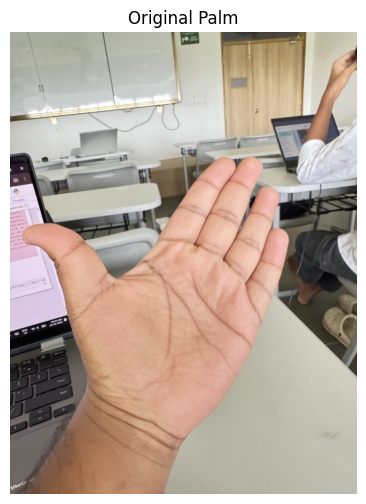

In [8]:
image = cv2.imread("IMG_7946.jpeg")

if image is None:
    print("Error: Could not load IMG_7946.jpeg")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    print(f"Image size: {image.shape[1]}x{image.shape[0]}")

    plt.figure(figsize=(6,6))
    plt.imshow(image_rgb)
    plt.title("Original Palm")
    plt.axis('off')
    plt.show()

---
## Method 1: CLAHE + Canny (Best for palm lines)

CLAHE enhances local contrast so faint palm lines become visible.

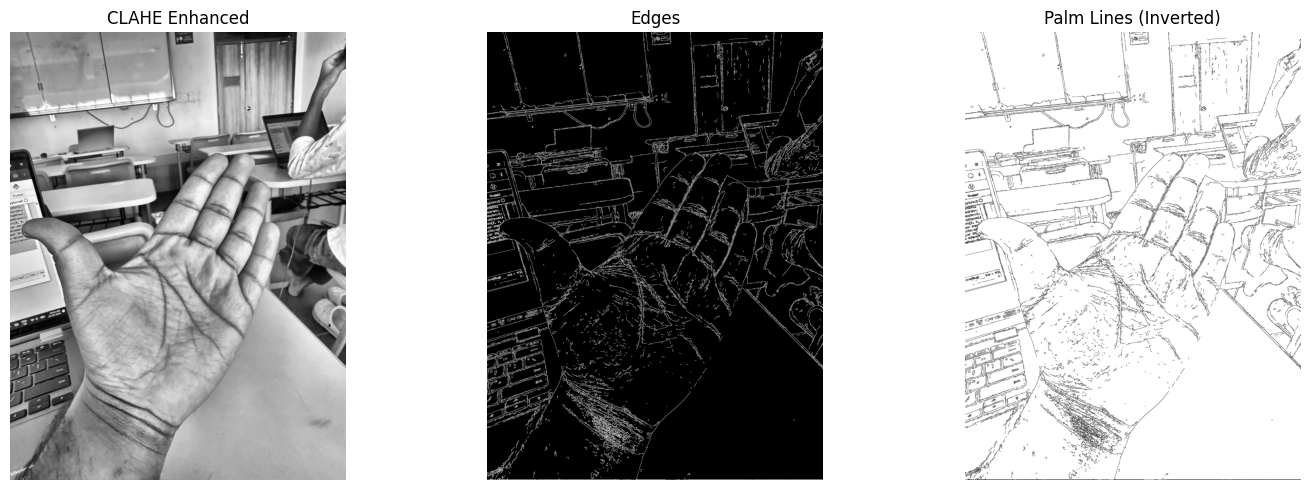

In [9]:
if image is not None:
    # Apply CLAHE for contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)

    # Blur slightly to reduce noise
    blurred = cv2.GaussianBlur(enhanced, (3, 3), 0)

    # Canny edge detection
    edges = cv2.Canny(blurred, 30, 60, apertureSize=3)

    # Dilate to connect broken line segments
    kernel = np.ones((2,2), np.uint8)
    edges = cv2.dilate(edges, kernel, iterations=1)

    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.imshow(enhanced, cmap='gray')
    plt.title("CLAHE Enhanced")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(edges, cmap='gray')
    plt.title("Edges")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(cv2.bitwise_not(edges), cmap='gray')
    plt.title("Palm Lines (Inverted)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

---
## Method 2: Adaptive Thresholding

Works well when lighting is uneven across the palm.

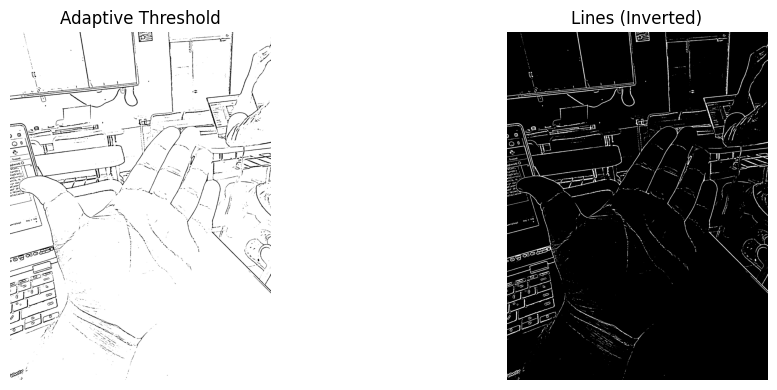

In [10]:
if image is not None:
    # Blur first
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Adaptive threshold
    thresh = cv2.adaptiveThreshold(
        blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 21, 4
    )

    # Morphological ops to clean noise
    kernel = np.ones((2,2), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.imshow(thresh, cmap='gray')
    plt.title("Adaptive Threshold")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(cv2.bitwise_not(thresh), cmap='gray')
    plt.title("Lines (Inverted)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

---
## Method 3: Sobel + Morphological Thinning

Gradient-based approach to highlight line structures.

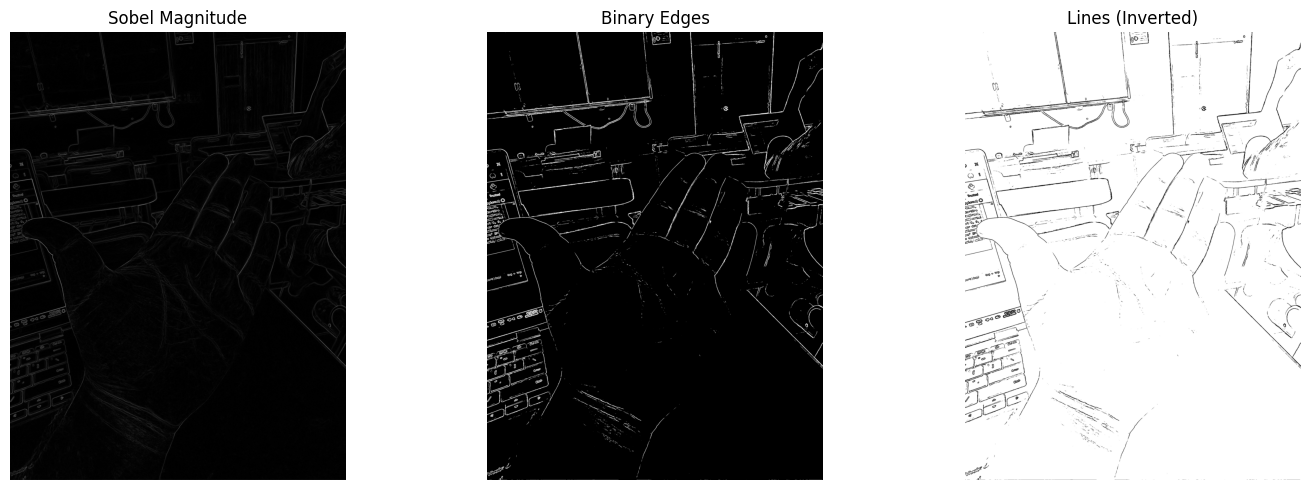

In [11]:
if image is not None:
    # CLAHE enhance
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    blurred = cv2.GaussianBlur(enhanced, (3, 3), 0)

    # Sobel gradient
    sobelx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sobelx**2 + sobely**2)
    mag = np.uint8(np.clip(mag / mag.max() * 255, 0, 255))

    # Threshold to binary
    _, mag_bin = cv2.threshold(mag, 30, 255, cv2.THRESH_BINARY)

    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.imshow(mag, cmap='gray')
    plt.title("Sobel Magnitude")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(mag_bin, cmap='gray')
    plt.title("Binary Edges")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(cv2.bitwise_not(mag_bin), cmap='gray')
    plt.title("Lines (Inverted)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

---
## Method 4: Line Detection with Hough Transform

Detects straight palm lines using probabilistic Hough lines.

Detected 6683 line segments


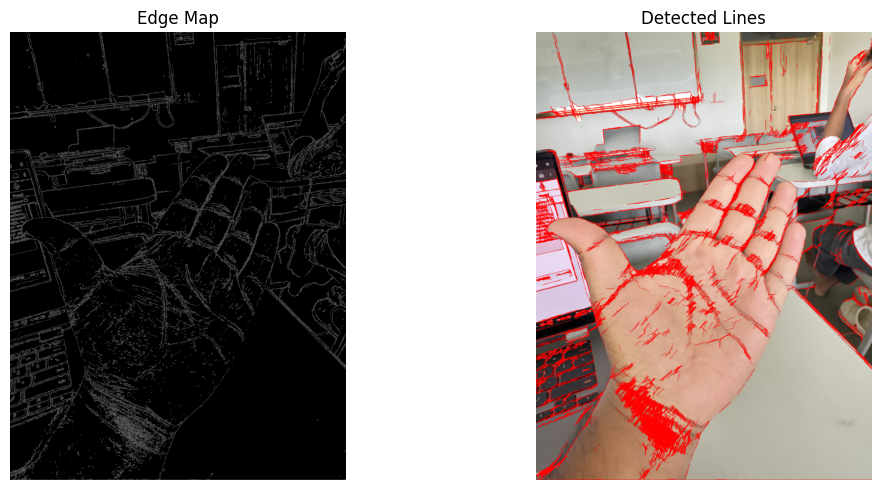

In [12]:
if image is not None:
    # CLAHE + Canny for good edge map
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    edges = cv2.Canny(enhanced, 30, 60, apertureSize=3)

    # Hough Line Transform
    lines = cv2.HoughLinesP(
        edges, rho=1, theta=np.pi/180,
        threshold=50, minLineLength=50, maxLineGap=20
    )

    result = image_rgb.copy()
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(result, (x1, y1), (x2, y2), (255, 0, 0), 2)
        print(f"Detected {len(lines)} line segments")
    else:
        print("No lines detected")

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.imshow(edges, cmap='gray')
    plt.title("Edge Map")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(result)
    plt.title("Detected Lines")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

---
## Tune Parameters for Best Result

Adjust the sliders below to find the best settings for your image.

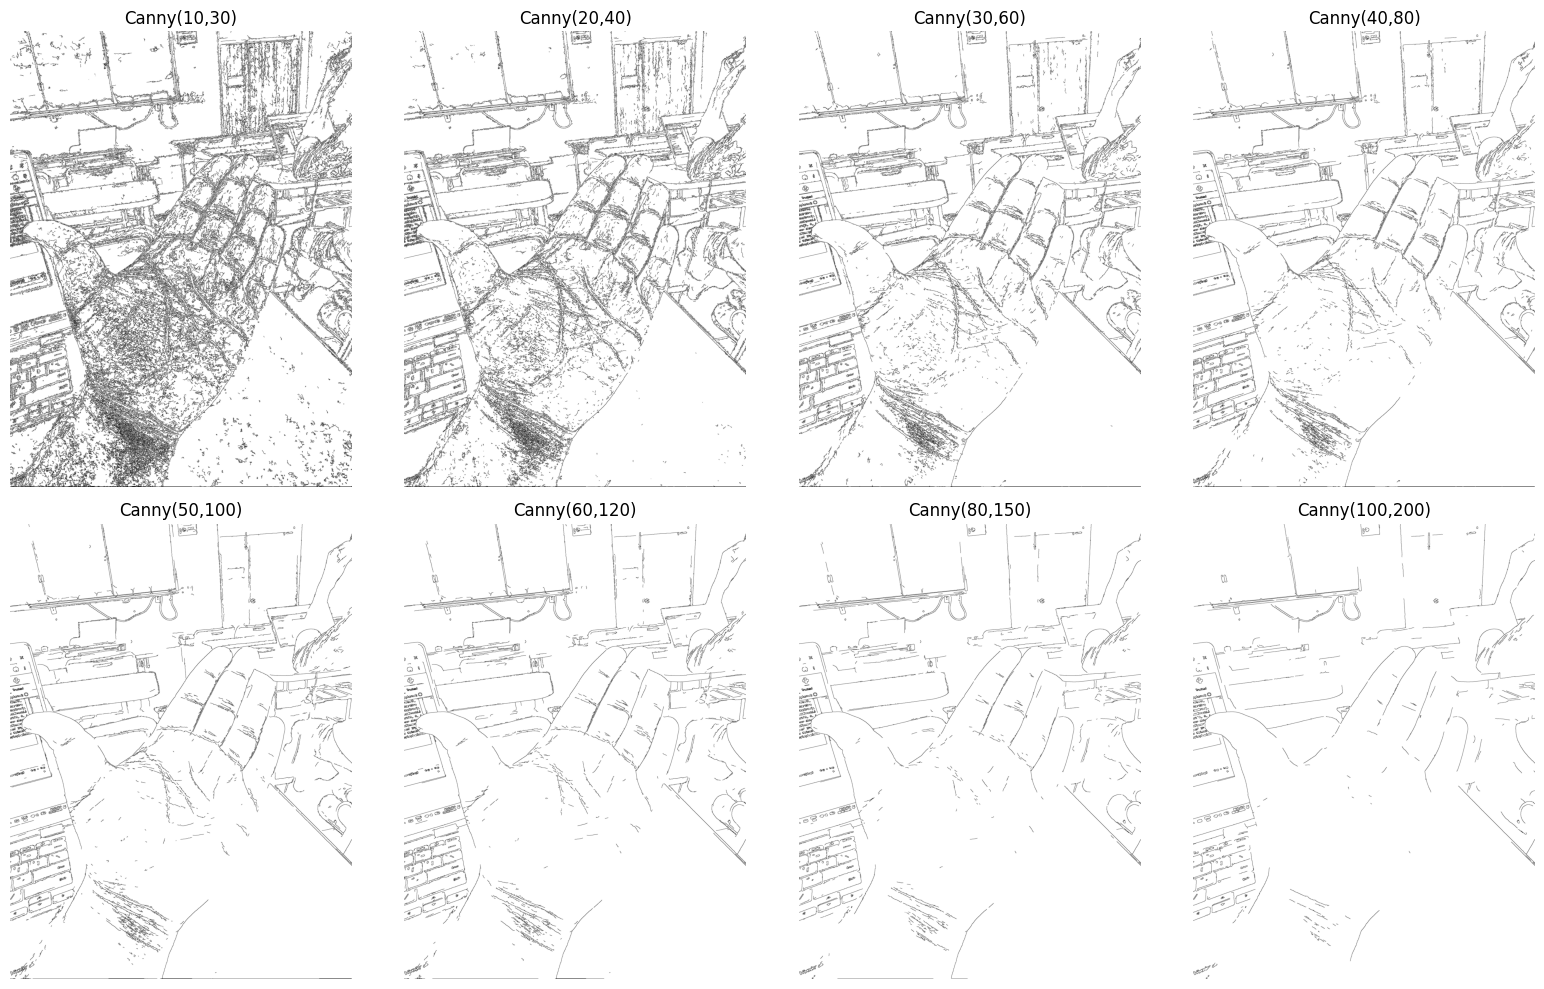

In [13]:
if image is not None:
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    blurred = cv2.GaussianBlur(enhanced, (3, 3), 0)

    # Try a wide range of Canny thresholds
    thresholds = [
        (10, 30), (20, 40), (30, 60), (40, 80), (50, 100),
        (60, 120), (80, 150), (100, 200)
    ]

    plt.figure(figsize=(16, 10))
    for i, (t1, t2) in enumerate(thresholds):
        e = cv2.Canny(blurred, t1, t2, apertureSize=3)
        kernel = np.ones((2,2), np.uint8)
        e = cv2.dilate(e, kernel, iterations=1)
        plt.subplot(2, 4, i + 1)
        plt.imshow(cv2.bitwise_not(e), cmap='gray')
        plt.title(f"Canny({t1},{t2})")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

---
## Overlay Lines on Original Image

Shows the detected palm lines overlaid on the original palm.

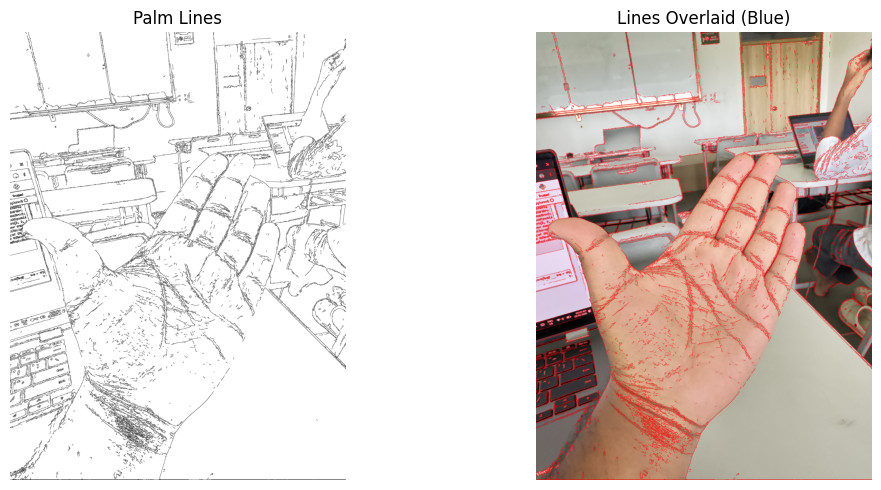

In [14]:
if image is not None:
    # Best approach: CLAHE + Canny
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    blurred = cv2.GaussianBlur(enhanced, (3, 3), 0)
    edges = cv2.Canny(blurred, 30, 60, apertureSize=3)
    kernel = np.ones((2,2), np.uint8)
    edges = cv2.dilate(edges, kernel, iterations=1)

    # Overlay
    overlay = image_rgb.copy()
    overlay[edges > 0] = [255, 0, 0]

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.imshow(cv2.bitwise_not(edges), cmap='gray')
    plt.title("Palm Lines")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(overlay)
    plt.title("Lines Overlaid (Blue)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()